In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv('/Iris.csv')


In [ ]:
df['is_setosa'] = (df['Species'] == 'Iris-setosa').astype(int)
df.drop(['Species', 'Id'], axis=1, inplace=True)
print(df.head())
print("\nclass distribution:")
print(df['is_setosa'].value_counts())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  is_setosa
0            5.1           3.5            1.4           0.2          1
1            4.9           3.0            1.4           0.2          1
2            4.7           3.2            1.3           0.2          1
3            4.6           3.1            1.5           0.2          1
4            5.0           3.6            1.4           0.2          1

class distribution:
is_setosa
0    100
1     50
Name: count, dtype: int64


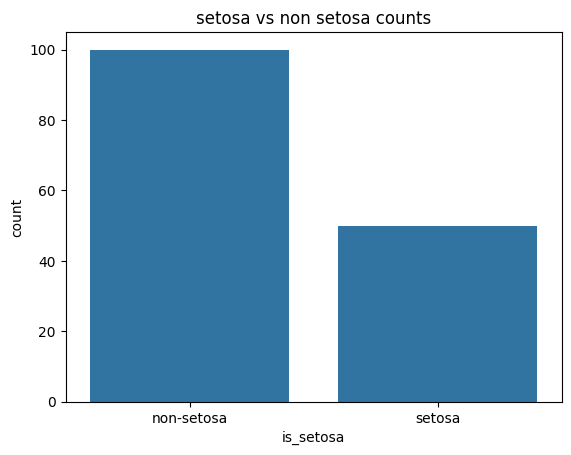

In [ ]:
sns.countplot(x = 'is_setosa', data = df)
plt.xticks([0,1], ['non-setosa', 'setosa'])
plt.title("setosa vs non setosa counts")
plt.show()

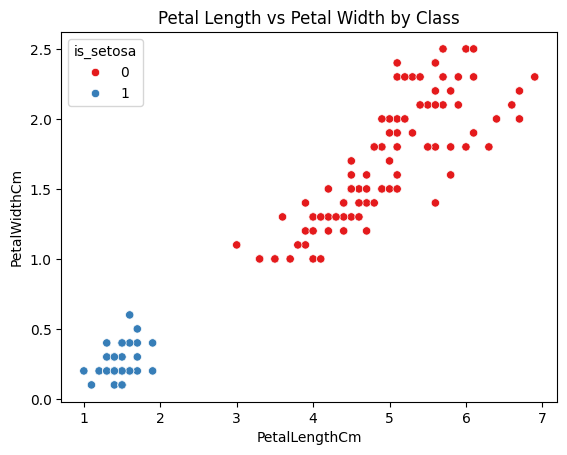

In [ ]:
sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='is_setosa',
    data=df,
    palette='Set1'
)
plt.title('Petal Length vs Petal Width by Class')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
x = df.drop('is_setosa', axis = 1)
y = df['is_setosa']
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify = y
                                                    )

print(f'Training samples: {x_train.shape[0]}')
print(f'Tested samples: {x_test.shape[0]}')

Training samples: 105
Tested samples: 45


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(x_train, y_train)
print("model training complete")

model training complete


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'model Accuracy on test set: {accuracy}')

model Accuracy on test set: 1.0


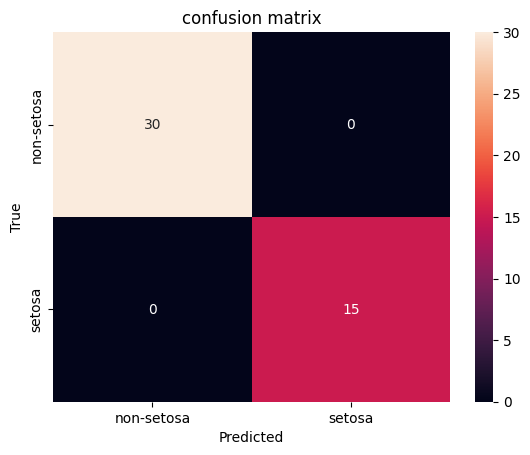

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True,fmt='d',
xticklabels=['non-setosa', 'setosa'],
yticklabels=['non-setosa', 'setosa']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('confusion matrix')
plt.show()

In [ ]:
coefs = pd.Series(model.coef_[0], index=x.columns)
print(coefs.sort_values(key=abs, ascending=False))


PetalLengthCm   -2.196944
PetalWidthCm    -0.863633
SepalWidthCm     0.822308
SepalLengthCm   -0.385424
dtype: float64
